
# Scikit-learn: Linear Regression and Logistic Regression with L1/L2 Regularization

This notebook demonstrates:
- Linear regression (`LinearRegression`, `Ridge`, `Lasso`) with evaluation and simple coefficient paths.
- Logistic regression (`LogisticRegression`, `LogisticRegressionCV`) with L2 and L1 penalties, and sparsity.


In [1]:

# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, load_breast_cancer, make_classification
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

import sklearn
print('sklearn', sklearn.__version__)


sklearn 1.5.0



## Part 1 — Linear Regression (L2/L1)

We'll create a synthetic regression dataset, split it, and compare **OLS**, **Ridge (L2)**, and **Lasso (L1)**. Features are standardized inside `Pipeline` to make penalties comparable.


In [2]:

# Data for regression
X_reg, y_reg = make_regression(n_samples=600, n_features=12, n_informative=8, noise=15.0, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

def fit_and_eval_reg(model, name):
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)
    rmse = mean_squared_error(yr_test, pred, squared=False)
    r2 = r2_score(yr_test, pred)
    return {'model': name, 'RMSE': rmse, 'R2': r2, 'pipe': pipe}

results = []
results.append(fit_and_eval_reg(LinearRegression(), 'OLS'))
results.append(fit_and_eval_reg(Ridge(alpha=1.0, random_state=42), 'Ridge L2 α=1.0'))
results.append(fit_and_eval_reg(Lasso(alpha=0.05, random_state=42, max_iter=5000), 'Lasso L1 α=0.05'))

pd.DataFrame([{k:v for k,v in r.items() if k in ['model','RMSE','R2']} for r in results])


,model,RMSE,R2
0,OLS,14.663621,0.992361
1,Ridge L2 α=1.0,14.671813,0.992353
2,Lasso L1 α=0.05,14.650451,0.992375



## Part 2 — Logistic Regression (L2/L1)

We use the Breast Cancer dataset. We'll compare **L2** and **L1** penalties. Scaling is important for penalized logistic regression.


In [3]:

# Data for classification
data = load_breast_cancer()
X_clf = data.data
y_clf = data.target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf)

# L2 logistic regression
logreg_l2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l2', C=1.0, solver='liblinear', random_state=42))
])
logreg_l2.fit(Xc_train, yc_train)
pred_l2 = logreg_l2.predict(Xc_test)
proba_l2 = logreg_l2.predict_proba(Xc_test)[:,1]

# L1 logistic regression
logreg_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42))
])
logreg_l1.fit(Xc_train, yc_train)
pred_l1 = logreg_l1.predict(Xc_test)
proba_l1 = logreg_l1.predict_proba(Xc_test)[:,1]

def summarize(name, y_true, y_pred, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    print(f"=== {name} ===")
    print("AUC:", round(auc, 4))
    print(classification_report(y_true, y_pred, digits=4))

summarize("LogReg L2 (C=1.0)", yc_test, pred_l2, proba_l2)
summarize("LogReg L1 (C=0.5)", yc_test, pred_l1, proba_l1)


=== LogReg L2 (C=1.0) ===
AUC: 0.9977
              precision    recall  f1-score   support

           0     0.9811    0.9811    0.9811        53
           1     0.9889    0.9889    0.9889        90

    accuracy                         0.9860       143
   macro avg     0.9850    0.9850    0.9850       143
weighted avg     0.9860    0.9860    0.9860       143

=== LogReg L1 (C=0.5) ===
AUC: 0.9981
              precision    recall  f1-score   support

           0     0.9811    0.9811    0.9811        53
           1     0.9889    0.9889    0.9889        90

    accuracy                         0.9860       143
   macro avg     0.9850    0.9850    0.9850       143
weighted avg     0.9860    0.9860    0.9860       143




### Sparsity: L1 vs L2

L1 encourages exact zeros. We count non‑zero coefficients after scaling.


Non‑zero coefficients — L2: 30
Non‑zero coefficients — L1: 12


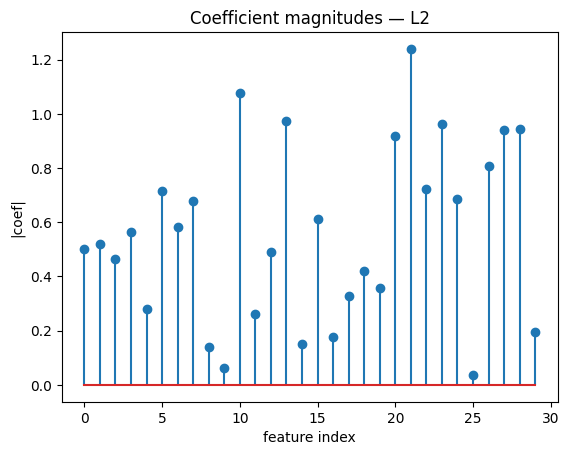

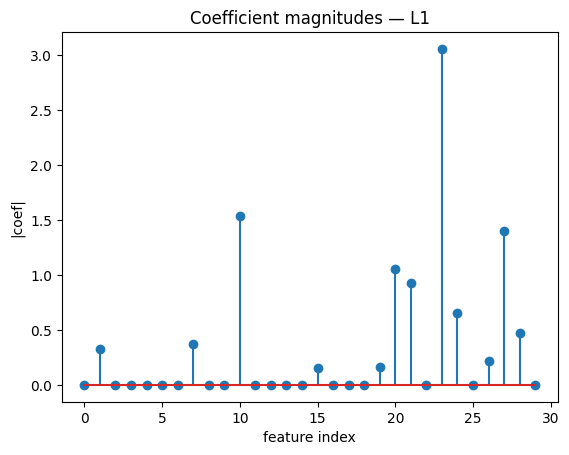

In [5]:

def count_nonzeros(pipeline):
    # Extract the trained logistic regression coefficients from the pipeline
    model = pipeline.named_steps['model']
    coef = model.coef_.ravel()
    return int(np.sum(coef != 0)), coef

nnz_l2, coef_l2 = count_nonzeros(logreg_l2)
nnz_l1, coef_l1 = count_nonzeros(logreg_l1)
print("Non‑zero coefficients — L2:", nnz_l2)
print("Non‑zero coefficients — L1:", nnz_l1)

plt.figure()
plt.stem(np.abs(coef_l2))
plt.title('Coefficient magnitudes — L2')
plt.xlabel('feature index'); plt.ylabel('|coef|')
plt.show()

plt.figure()
plt.stem(np.abs(coef_l1))
plt.title('Coefficient magnitudes — L1')
plt.xlabel('feature index'); plt.ylabel('|coef|')
plt.show()



## Notes

- **L2 (Ridge/weight decay)** shrinks all coefficients smoothly and stabilizes optimization.
- **L1 (Lasso)** promotes sparsity by pushing many coefficients to exactly zero (feature selection).
- For logistic regression, use `solver='liblinear'` or `solver='saga'` to enable `penalty='l1'`. For multi‑class, prefer `saga`.
- Always scale features when using penalties so one feature's units don't dominate the penalty.
- `C` in logistic regression is the inverse of penalty strength. In Ridge/Lasso, `alpha` is the direct penalty strength.
